<a href="https://colab.research.google.com/github/pradipdas9040/Machine-Learning-2/blob/main/AgenticAI/04_conditional_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install langchain-ollama

In [2]:
%%capture
!sudo apt-get install -y zstd

In [3]:
%%capture
!curl -fsSL https://ollama.com/install.sh | sh

In [4]:
# Start Ollama service in the background
import subprocess
import os

# Set OLLAMA_HOST to '0.0.0.0' to make it accessible from inside the Colab VM.
os.environ['OLLAMA_HOST'] = '0.0.0.0'

# Start Ollama server in a new process
ollama_process = subprocess.Popen(['ollama', 'serve'])

# Wait a bit for the server to start (adjust if needed)
import time
time.sleep(5)

print("Ollama server started.")

Ollama server started.


In [5]:
%%capture
!ollama pull qwen2.5:3b

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
import operator

In [7]:
model = ChatOllama(
    model="qwen2.5:3b",
    temperature=0
)

In [8]:
class structuredOutput(BaseModel):
  sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")

structured_model = model.with_structured_output(structuredOutput)

In [9]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [10]:
prompt = "What is the sentiment of following review - The software is too bad"

structured_model.invoke(prompt)

structuredOutput(sentiment='negative')

In [11]:
class ReviewState(TypedDict):
  review: str
  sentiment: Literal["positive", "negative"]
  diagnosis: dict
  analysis_feedback: str
  response: str


def get_sentiment(state: ReviewState) -> dict:

  prompt = f"For the following reviews find out the sentiment \n {state['review']}"
  response = structured_model.invoke(prompt).sentiment

  return {'sentiment': response}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

  if state['sentiment'] == "positive":
    return "positive_response"
  else:
    return "run_diagnosis"

def positive_response(state: ReviewState) -> dict:

  prompt = f"""
    Write a warm thank-you message in response to this review:
      \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website.
  """
  response = model.invoke(prompt).content

  return {'response': response}


def run_diagnosis(state: ReviewState) -> dict:

  prompt = f"""
    Diagnose this negative review:\n\n{state['review']}\n
    Return issue_type, tone, and urgency.
  """
  response = diagnosis_model.invoke(prompt)

  return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

  diagnosis = state['diagnosis']

  prompt = f"""
    You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
  """
  response = model.invoke(prompt).content

  return {'response': response}

In [12]:
graph = StateGraph(ReviewState)

graph.add_node("get_sentiment", get_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "get_sentiment")
graph.add_conditional_edges("get_sentiment", check_sentiment)
graph.add_edge("positive_response", END)
graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("negative_response", END)

workflow = graph.compile()

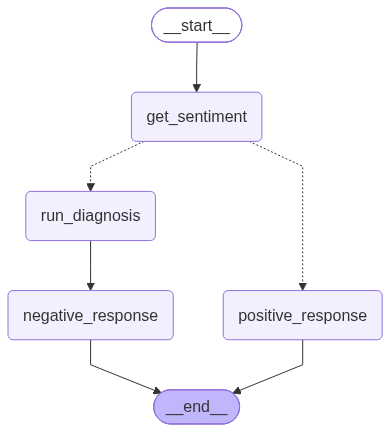

In [13]:
workflow

In [14]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
result = workflow.invoke(intial_state)

In [15]:
result

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Performance',
  'tone': 'frustrated',
  'urgency': 'high'},
 'response': "Hi there,\n\nI'm really sorry to hear that you're facing difficulties with your performance. I understand how frustrating this must be for you, especially given the high level of urgency you've indicated.\n\nLet's work together on finding a solution as quickly as possible. Could you please provide me with more details about what specifically is causing the issue? The more information we have, the better equipped I'll be to assist you in resolving it promptly.\n\nI'm here for you and want to ensure that everything goes smoothly. Please let me know if there's anything else I can do to help make this situation easier for

In [16]:
intial_state={
    'review': "I’ve been using this app about a month now, and I must say the user interfase is incredibly clean and intuitive."
}
result2 = workflow.invoke(intial_state)

In [17]:
result2

{'review': 'I’ve been using this app about a month now, and I must say the user interfase is incredibly clean and intuitive.',
 'sentiment': 'positive',
 'response': "Dear [User],\n\nI am thrilled to hear that you have found our app's user interface to be incredibly clean and intuitive after just one month of use. Your positive feedback means a great deal to us.\n\nYour experience is invaluable to us, and we are committed to continuously improving the app based on your insights. We appreciate your time in sharing such a thoughtful review with us.\n\nWe would love it if you could take a moment to share your thoughts about our app further by leaving some feedback on our website. Your input will help us make even more improvements for future users like yourself.\n\nThank you once again for taking the time to provide this positive feedback and for considering sharing additional insights through our website. We look forward to continuing to serve you well.\n\nBest regards,\n[Your Name]\nAli